# 02 Preprocessing and Exploratory Data Analysis

This notebook performs the second implementation phase of the MetroPT-3 predictive maintenance project.

**Purpose**
- Load the raw MetroPT-3 dataset.
- Parse and sort timestamps chronologically.
- Check and handle missing values.
- Remove duplicate timestamps using a clear rule.
- Save a cleaned dataset for later feature engineering.
- Generate EDA tables and figures for the dissertation.

**Important**
- This notebook does not create machine-learning labels yet.
- This notebook does not train models.
- Feature engineering and early-warning labels are completed in later notebooks.

In [5]:
# 1. Import libraries and confirm environment
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Python executable:", sys.executable)
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

Python executable: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\.venv\Scripts\python.exe
pandas version: 3.0.5
numpy version: 2.5.2


In [6]:
# 2. Set project paths
current_dir = Path.cwd()

if current_dir.name.lower() == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)
print("Processed data folder:", PROCESSED_DATA_DIR)
print("Tables output folder:", OUTPUT_TABLES_DIR)
print("Figures output folder:", OUTPUT_FIGURES_DIR)

Project root: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter
Raw data folder: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\data\raw
Processed data folder: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\data\processed
Tables output folder: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\outputs\tables
Figures output folder: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\outputs\figures


In [7]:
# 3. Locate and load the raw dataset
csv_files = sorted(list(RAW_DATA_DIR.glob("*.csv")))

print("CSV files found in data/raw/:")
for file in csv_files:
    print("-", file.name)

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file found in data/raw/. Place the raw MetroPT-3 CSV file inside data/raw/."
    )

# If more than one CSV exists, the first file alphabetically is used.
# Manually replace data_path if needed.
data_path = csv_files[0]

df_raw = pd.read_csv(data_path, low_memory=False)

print("Loaded dataset:", data_path.name)
print("Raw shape:", df_raw.shape)
df_raw.head()

CSV files found in data/raw/:
- MetroPT3(AirCompressor).csv
Loaded dataset: MetroPT3(AirCompressor).csv
Raw shape: (1516948, 17)


,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [8]:
# 4. Inspect columns and data types
print("Column names:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes)

column_metadata = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": [str(dtype) for dtype in df_raw.dtypes],
    "non_null_count": [df_raw[col].notna().sum() for col in df_raw.columns],
    "missing_count": [df_raw[col].isna().sum() for col in df_raw.columns]
})

column_metadata.to_csv(OUTPUT_TABLES_DIR / "column_metadata.csv", index=False)
column_metadata

Column names:
['Unnamed: 0', 'timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

Data types:
Unnamed: 0           int64
timestamp              str
TP2                float64
TP3                float64
H1                 float64
DV_pressure        float64
Reservoirs         float64
Oil_temperature    float64
Motor_current      float64
COMP               float64
DV_eletric         float64
Towers             float64
MPG                float64
LPS                float64
Pressure_switch    float64
Oil_level          float64
Caudal_impulses    float64
dtype: object


,column,dtype,non_null_count,missing_count
0,Unnamed: 0,int64,1516948,0
1,timestamp,str,1516948,0
2,TP2,float64,1516948,0
3,TP3,float64,1516948,0
4,H1,float64,1516948,0
5,DV_pressure,float64,1516948,0
6,Reservoirs,float64,1516948,0
7,Oil_temperature,float64,1516948,0
8,Motor_current,float64,1516948,0
9,COMP,float64,1516948,0


In [9]:
# 5. Detect timestamp column
possible_timestamp_cols = [
    "timestamp", "Timestamp", "time", "Time", "datetime", "Datetime", "date", "Date"
]

timestamp_col = None
for col in possible_timestamp_cols:
    if col in df_raw.columns:
        timestamp_col = col
        break

if timestamp_col is None:
    print("Available columns:")
    print(df_raw.columns.tolist())
    raise ValueError("No timestamp column was detected. Manually set timestamp_col.")

print("Detected timestamp column:", timestamp_col)

Detected timestamp column: timestamp


In [10]:
# 6. Parse timestamps and sort chronologically
df = df_raw.copy()

original_rows = df.shape[0]
original_columns = df.shape[1]

df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")

invalid_timestamps = df[timestamp_col].isna().sum()
print("Invalid timestamps:", invalid_timestamps)

# Remove rows with invalid timestamps.
df = df.dropna(subset=[timestamp_col]).copy()

# Sort chronologically.
df = df.sort_values(timestamp_col).reset_index(drop=True)

print("Shape after timestamp parsing:", df.shape)
print("Dataset start:", df[timestamp_col].min())
print("Dataset end:", df[timestamp_col].max())
df.head()

Invalid timestamps: 0
Shape after timestamp parsing: (1516948, 17)
Dataset start: 2020-02-01 00:00:00
Dataset end: 2020-09-01 03:59:50


,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [11]:
# 7. Check and handle duplicate timestamps
duplicate_count_before = df.duplicated(subset=[timestamp_col]).sum()
print("Duplicate timestamps before handling:", duplicate_count_before)

# Rule: if duplicate timestamps exist, keep the first occurrence after chronological sorting.
df = df.drop_duplicates(subset=[timestamp_col], keep="first").reset_index(drop=True)

duplicate_count_after = df.duplicated(subset=[timestamp_col]).sum()
print("Duplicate timestamps after handling:", duplicate_count_after)
print("Shape after duplicate handling:", df.shape)

duplicate_summary = pd.DataFrame({
    "item": ["duplicate_timestamps_before_handling", "duplicate_timestamps_after_handling"],
    "value": [duplicate_count_before, duplicate_count_after]
})
duplicate_summary.to_csv(OUTPUT_TABLES_DIR / "duplicate_timestamps_summary.csv", index=False)
duplicate_summary

Duplicate timestamps before handling: 0
Duplicate timestamps after handling: 0
Shape after duplicate handling: (1516948, 17)


,item,value
0,duplicate_timestamps_before_handling,0
1,duplicate_timestamps_after_handling,0


In [12]:
# 8. Missing value audit and handling
missing_before = df.isna().sum().reset_index()
missing_before.columns = ["column", "missing_before"]
missing_before["missing_before_pct"] = (missing_before["missing_before"] / len(df)) * 100

total_missing_before = int(df.isna().sum().sum())
print("Total missing values before handling:", total_missing_before)

# Forward fill uses previous observations only, avoiding future leakage.
df_clean = df.ffill()

remaining_after_ffill = int(df_clean.isna().sum().sum())
print("Missing values after forward fill:", remaining_after_ffill)

# Drop any remaining leading missing rows.
if remaining_after_ffill > 0:
    df_clean = df_clean.dropna().reset_index(drop=True)

total_missing_after = int(df_clean.isna().sum().sum())
print("Total missing values after final handling:", total_missing_after)
print("Cleaned shape:", df_clean.shape)

missing_after = df_clean.isna().sum().reset_index()
missing_after.columns = ["column", "missing_after"]
missing_after["missing_after_pct"] = (missing_after["missing_after"] / len(df_clean)) * 100

missing_summary = missing_before.merge(missing_after, on="column", how="outer")
missing_summary.to_csv(OUTPUT_TABLES_DIR / "missing_values_before_after.csv", index=False)
missing_summary

Total missing values before handling: 0
Missing values after forward fill: 0
Total missing values after final handling: 0
Cleaned shape: (1516948, 17)


,column,missing_before,missing_before_pct,missing_after,missing_after_pct
0,COMP,0,0.0,0,0.0
1,Caudal_impulses,0,0.0,0,0.0
2,DV_eletric,0,0.0,0,0.0
3,DV_pressure,0,0.0,0,0.0
4,H1,0,0.0,0,0.0
5,LPS,0,0.0,0,0.0
6,MPG,0,0.0,0,0.0
7,Motor_current,0,0.0,0,0.0
8,Oil_level,0,0.0,0,0.0
9,Oil_temperature,0,0.0,0,0.0


In [13]:
# 9. Identify expected sensor columns
expected_numerical_sensors = [
    "TP2", "TP3", "H1", "DV_pressure", "Reservoirs",
    "Oil_temperature", "Motor_current", "Caudal_impulses"
]

expected_digital_signals = [
    "COMP", "DV_eletric", "Towers", "MPG", "LPS", "Pressure_switch", "Oil_level"
]

available_numerical_sensors = [col for col in expected_numerical_sensors if col in df_clean.columns]
available_digital_signals = [col for col in expected_digital_signals if col in df_clean.columns]
missing_expected_cols = [
    col for col in expected_numerical_sensors + expected_digital_signals if col not in df_clean.columns
]

print("Available numerical sensors:", available_numerical_sensors)
print("Available digital signals:", available_digital_signals)
print("Expected columns not found:", missing_expected_cols)

sensor_groups = pd.DataFrame({
    "group": ["Numerical sensors", "Digital signals", "Expected columns not found"],
    "columns": [
        ", ".join(available_numerical_sensors),
        ", ".join(available_digital_signals),
        ", ".join(missing_expected_cols) if missing_expected_cols else "None"
    ]
})

sensor_groups.to_csv(OUTPUT_TABLES_DIR / "sensor_groups.csv", index=False)
sensor_groups

Available numerical sensors: ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'Caudal_impulses']
Available digital signals: ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level']
Expected columns not found: []


,group,columns
0,Numerical sensors,"TP2, TP3, H1, DV_pressure, Reservoirs, Oil_tem..."
1,Digital signals,"COMP, DV_eletric, Towers, MPG, LPS, Pressure_s..."
2,Expected columns not found,None


In [14]:
# 10. Save cleaned dataset
cleaned_path = PROCESSED_DATA_DIR / "metropt3_cleaned.csv"
df_clean.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved to:", cleaned_path)
print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset saved to: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\data\processed\metropt3_cleaned.csv
Cleaned dataset shape: (1516948, 17)


In [15]:
# 11. Save preprocessing summary
preprocessing_summary = pd.DataFrame({
    "item": [
        "raw_dataset_file",
        "original_rows",
        "original_columns",
        "invalid_timestamps_removed",
        "duplicate_timestamps_before_handling",
        "duplicate_timestamps_after_handling",
        "total_missing_values_before_handling",
        "total_missing_values_after_handling",
        "cleaned_rows",
        "cleaned_columns",
        "dataset_start",
        "dataset_end"
    ],
    "value": [
        data_path.name,
        original_rows,
        original_columns,
        invalid_timestamps,
        duplicate_count_before,
        duplicate_count_after,
        total_missing_before,
        total_missing_after,
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean[timestamp_col].min(),
        df_clean[timestamp_col].max()
    ]
})

preprocessing_summary.to_csv(OUTPUT_TABLES_DIR / "preprocessing_summary.csv", index=False)
preprocessing_summary

,item,value
0,raw_dataset_file,MetroPT3(AirCompressor).csv
1,original_rows,1516948
2,original_columns,17
3,invalid_timestamps_removed,0
4,duplicate_timestamps_before_handling,0
5,duplicate_timestamps_after_handling,0
6,total_missing_values_before_handling,0
7,total_missing_values_after_handling,0
8,cleaned_rows,1516948
9,cleaned_columns,17


In [16]:
# 12. Summary statistics for numerical sensors
if len(available_numerical_sensors) == 0:
    raise ValueError("No expected numerical sensors were found in the dataset.")

sensor_summary_statistics = df_clean[available_numerical_sensors].describe().T
sensor_summary_statistics.to_csv(OUTPUT_TABLES_DIR / "sensor_summary_statistics.csv")
sensor_summary_statistics

,count,mean,std,min,25%,50%,75%,max
TP2,1516948.0,1.367826,3.250930,-0.032,-0.014,-0.012,-0.0100,10.676
TP3,1516948.0,8.984611,0.639095,0.730,8.492,8.960,9.4920,10.302
H1,1516948.0,7.568155,3.333200,-0.036,8.254,8.784,9.3740,10.288
DV_pressure,1516948.0,0.055956,0.382402,-0.032,-0.022,-0.020,-0.0180,9.844
Reservoirs,1516948.0,8.985233,0.638307,0.712,8.494,8.960,9.4920,10.300
Oil_temperature,1516948.0,62.644182,6.516261,15.400,57.775,62.700,67.2500,89.050
Motor_current,1516948.0,2.050171,2.302053,0.020,0.040,0.045,3.8075,9.295
Caudal_impulses,1516948.0,0.937107,0.242771,0.000,1.000,1.000,1.0000,1.000


In [17]:
# 13. Prepare hourly resampled data for readable time-series plots
plot_df = df_clean[[timestamp_col] + available_numerical_sensors].copy()
plot_df = plot_df.set_index(timestamp_col)

# Hourly averaging avoids overplotting on the full 1.5M-row dataset.
plot_hourly = plot_df.resample("1h").mean()

print("Hourly plot data shape:", plot_hourly.shape)
plot_hourly.head()

Hourly plot data shape: (5116, 8)


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,Caudal_impulses
timestamp,,,,,,,,
2020-02-01 00:00:00,0.502011,8.881566,8.364978,-0.022951,8.881995,51.893750,0.897370,1.0
2020-02-01 01:00:00,0.241003,8.984066,8.720182,-0.023030,8.984551,51.912397,1.009373,1.0
2020-02-01 02:00:00,0.485587,9.014171,8.500303,-0.023427,9.014320,51.719008,1.281343,1.0
2020-02-01 03:00:00,0.492347,8.981570,8.443317,-0.023559,8.982066,51.396763,1.286625,1.0
2020-02-01 04:00:00,0.508242,8.996973,8.458462,-0.023797,8.997637,52.172802,1.265721,1.0


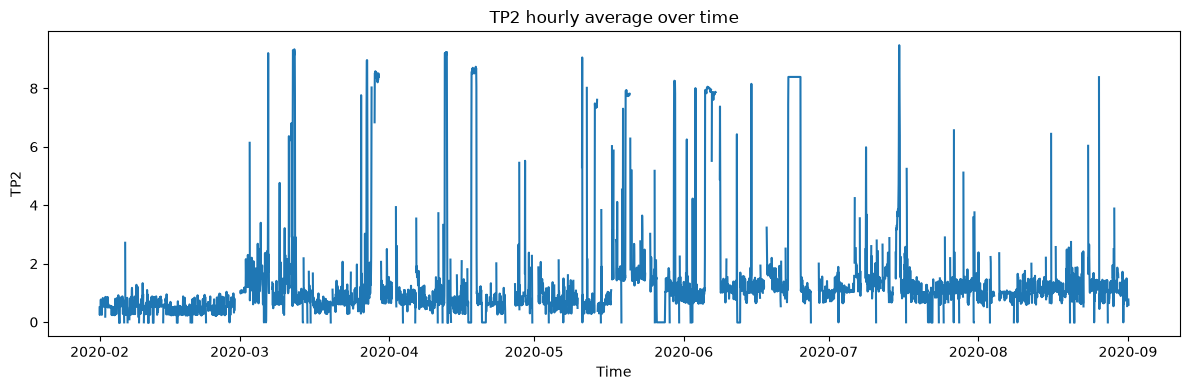

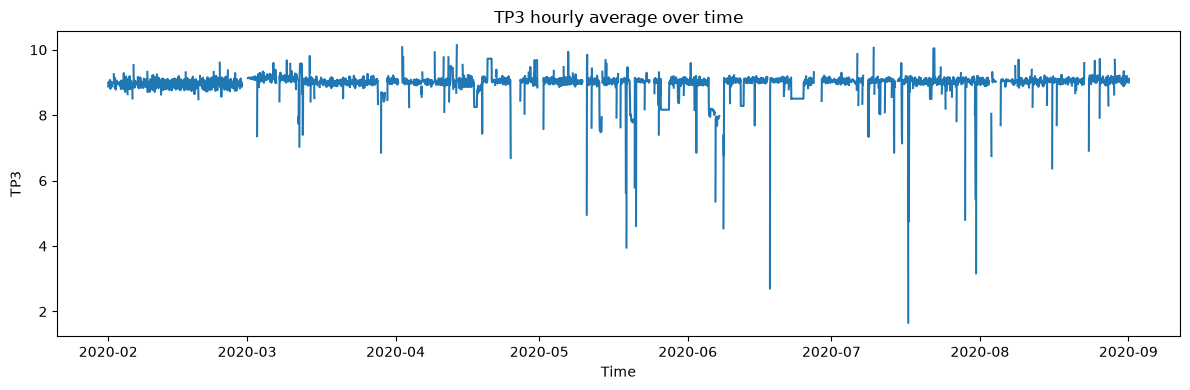

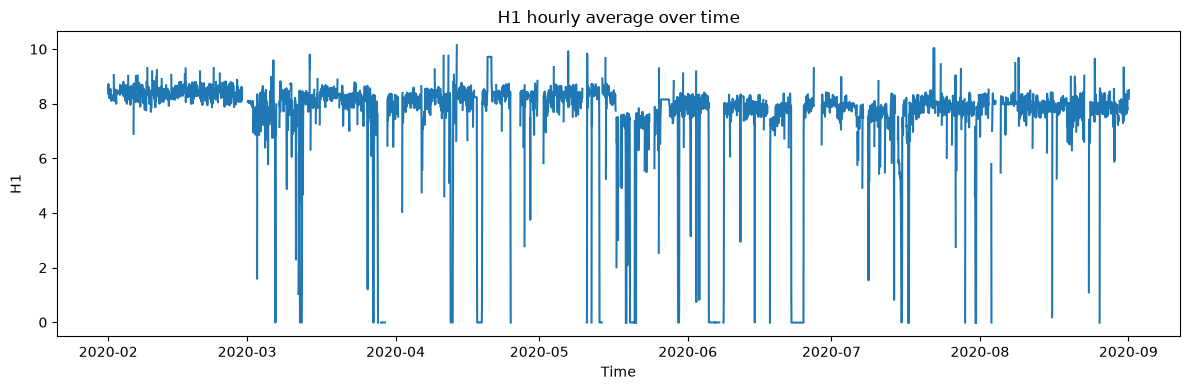

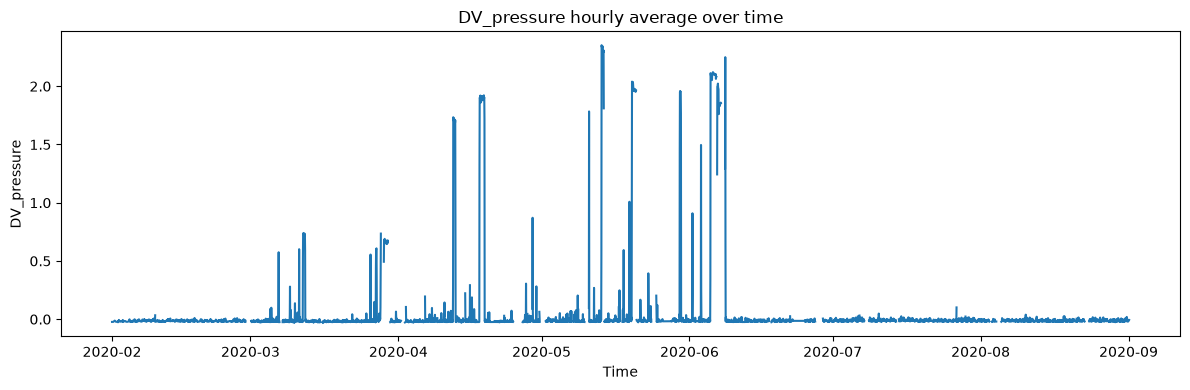

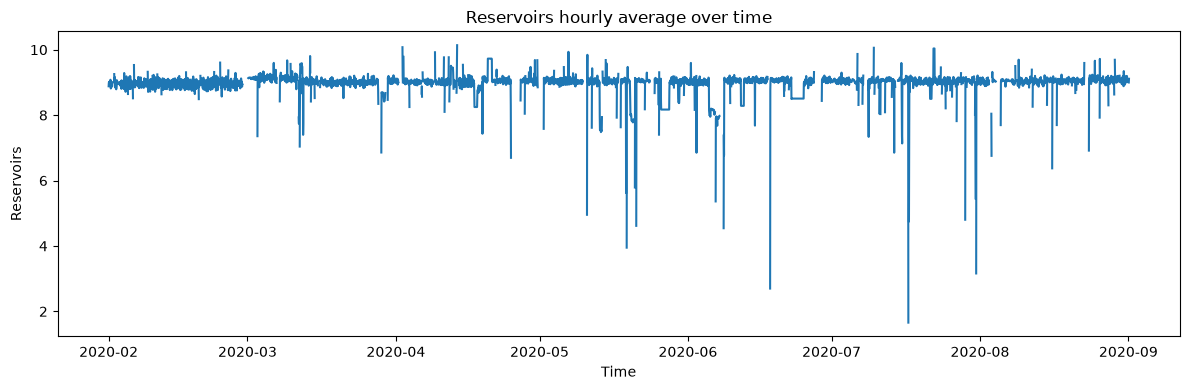

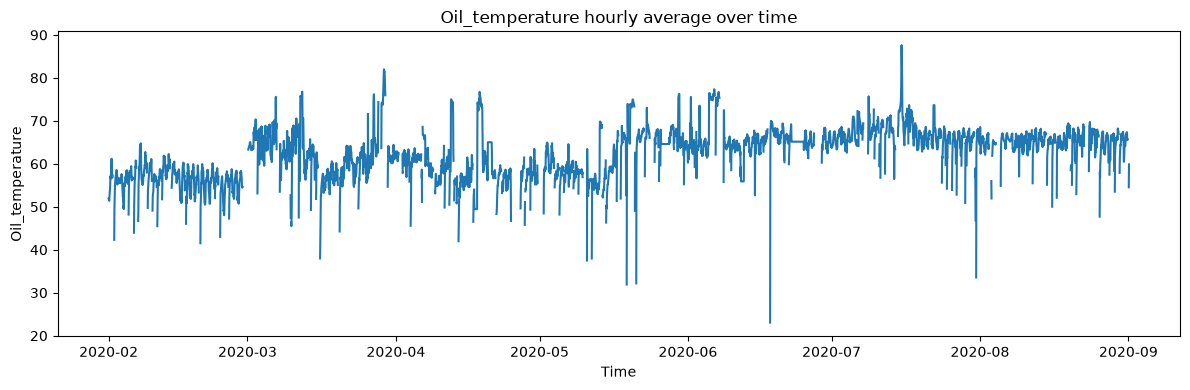

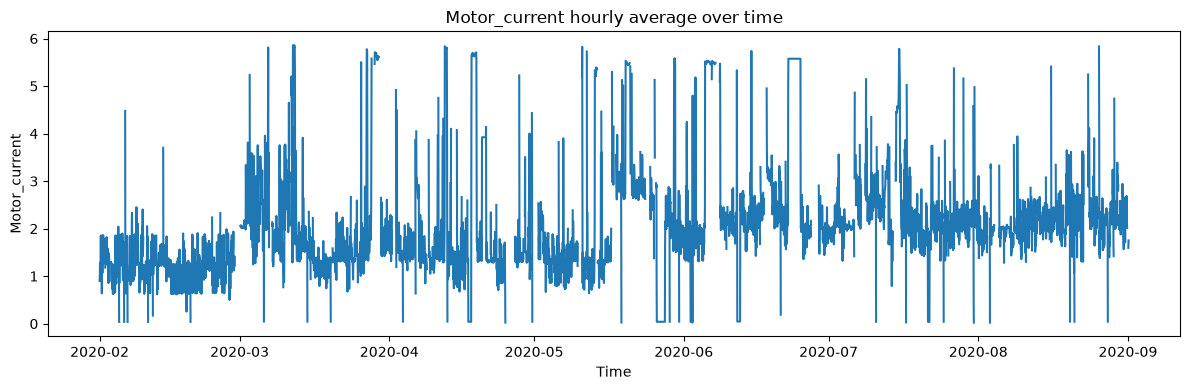

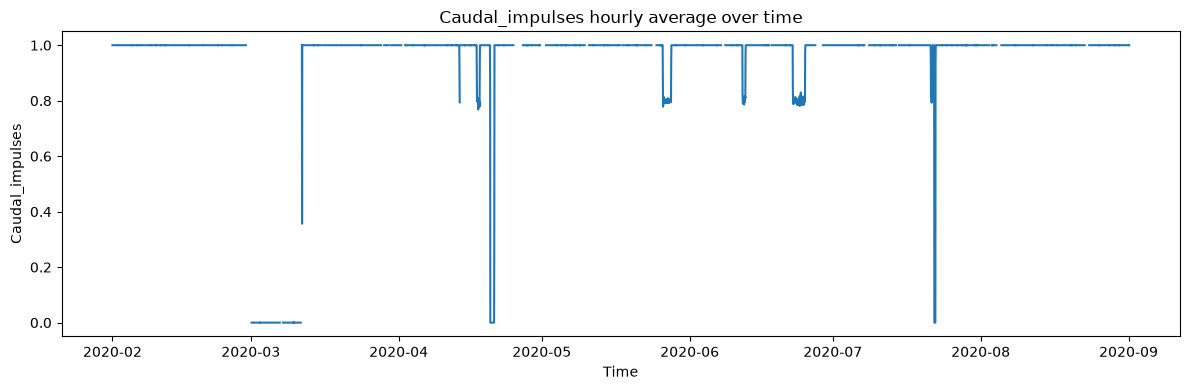

In [18]:
# 14. Plot individual hourly trends for numerical sensors
for sensor in available_numerical_sensors:
    plt.figure(figsize=(12, 4))
    plt.plot(plot_hourly.index, plot_hourly[sensor])
    plt.title(f"{sensor} hourly average over time")
    plt.xlabel("Time")
    plt.ylabel(sensor)
    plt.tight_layout()
    plt.savefig(OUTPUT_FIGURES_DIR / f"{sensor}_hourly_timeseries.png", dpi=300)
    plt.show()

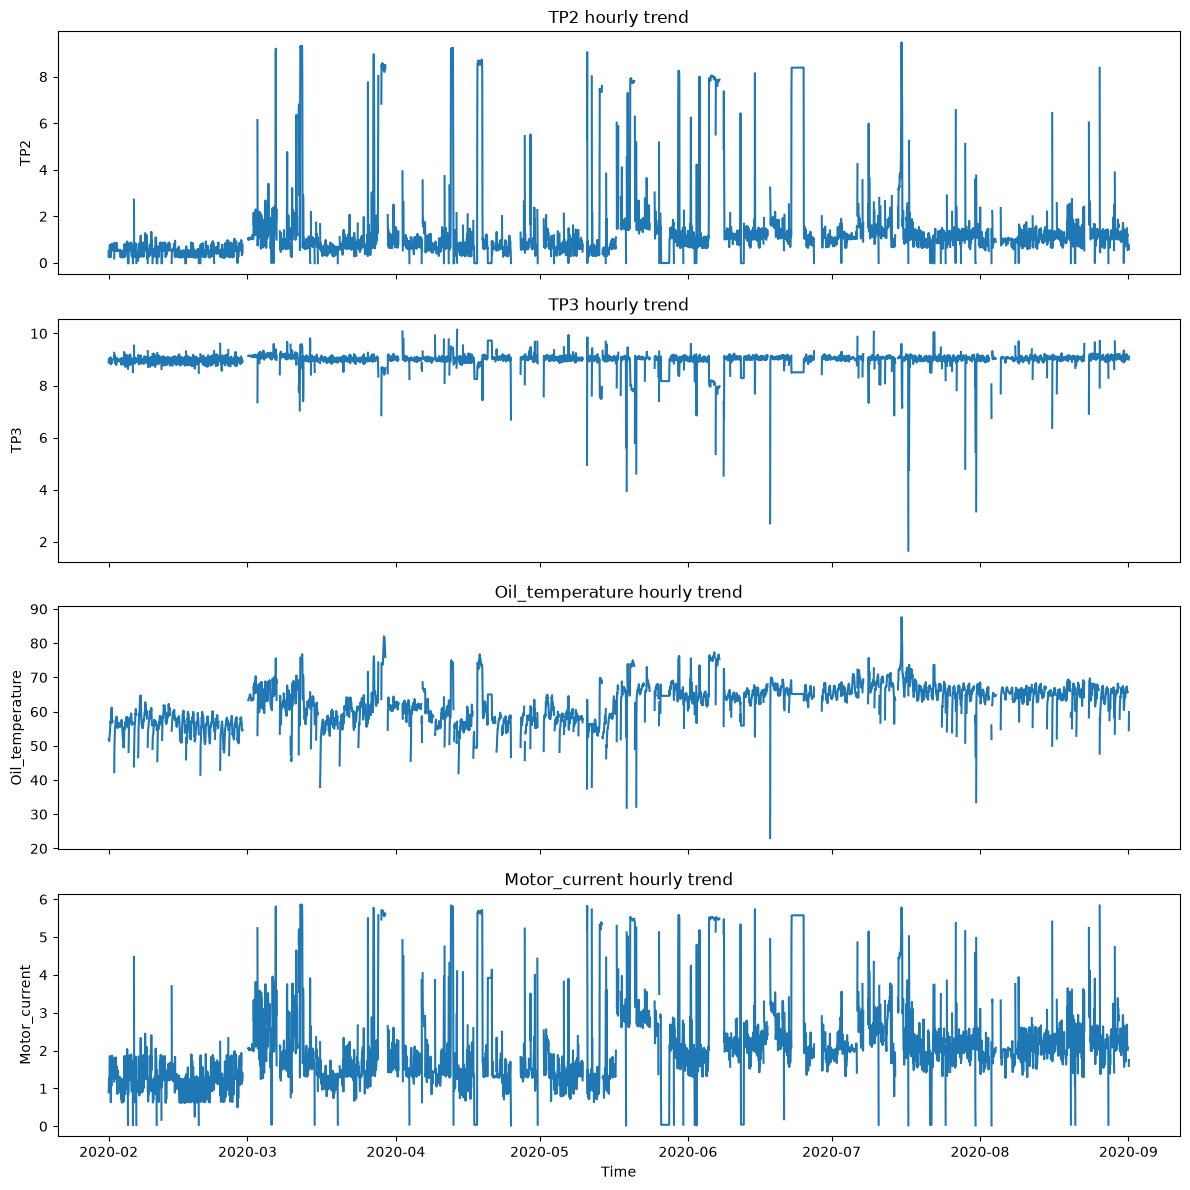

In [19]:
# 15. Plot selected key sensor trends in one figure
key_sensors = [col for col in ["TP2", "TP3", "Oil_temperature", "Motor_current"] if col in df_clean.columns]

if len(key_sensors) == 0:
    raise ValueError("No key sensors found for combined trend plot.")

fig, axes = plt.subplots(len(key_sensors), 1, figsize=(12, 3 * len(key_sensors)), sharex=True)
if len(key_sensors) == 1:
    axes = [axes]

for ax, sensor in zip(axes, key_sensors):
    ax.plot(plot_hourly.index, plot_hourly[sensor])
    ax.set_title(f"{sensor} hourly trend")
    ax.set_ylabel(sensor)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "key_sensor_hourly_trends.png", dpi=300)
plt.show()

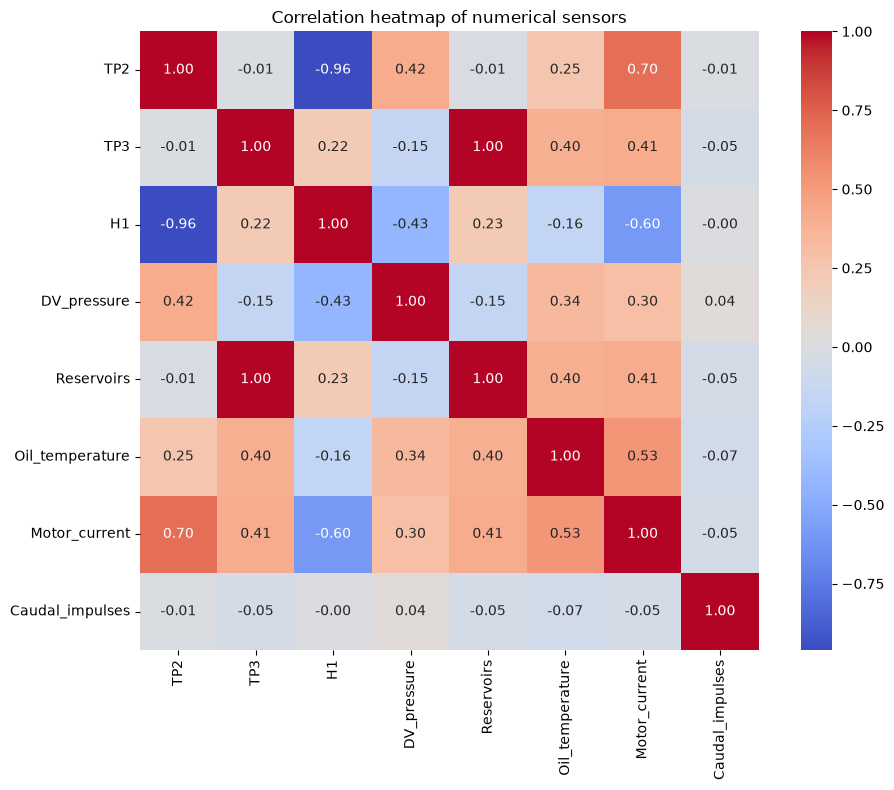

,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,Caudal_impulses
TP2,1.000000,-0.011161,-0.961269,0.415025,-0.012403,0.250710,0.697480,-0.010397
TP3,-0.011161,1.000000,0.224867,-0.153074,0.999993,0.401616,0.413756,-0.053179
H1,-0.961269,0.224867,1.000000,-0.425513,0.226037,-0.161810,-0.600178,-0.001900
DV_pressure,0.415025,-0.153074,-0.425513,1.000000,-0.153080,0.339697,0.302160,0.042388
Reservoirs,-0.012403,0.999993,0.226037,-0.153080,1.000000,0.401647,0.412691,-0.052300
Oil_temperature,0.250710,0.401616,-0.161810,0.339697,0.401647,1.000000,0.528739,-0.068120
Motor_current,0.697480,0.413756,-0.600178,0.302160,0.412691,0.528739,1.000000,-0.051145
Caudal_impulses,-0.010397,-0.053179,-0.001900,0.042388,-0.052300,-0.068120,-0.051145,1.000000


In [20]:
# 16. Correlation heatmap for numerical sensors
correlation_matrix = df_clean[available_numerical_sensors].corr()
correlation_matrix.to_csv(OUTPUT_TABLES_DIR / "correlation_matrix.csv")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation heatmap of numerical sensors")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "correlation_heatmap.png", dpi=300)
plt.show()

correlation_matrix

Distribution plot sample size: 100000


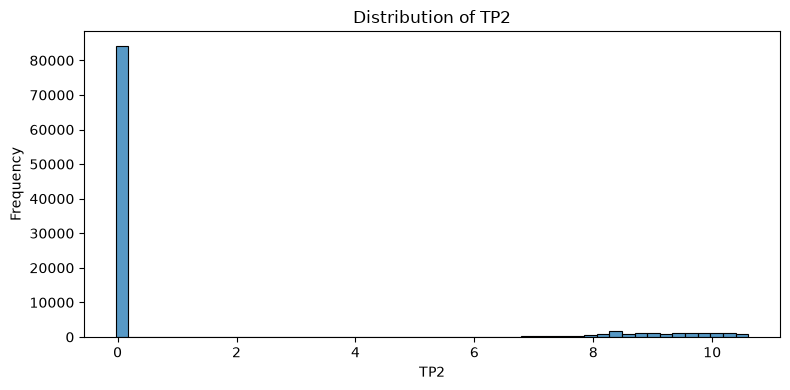

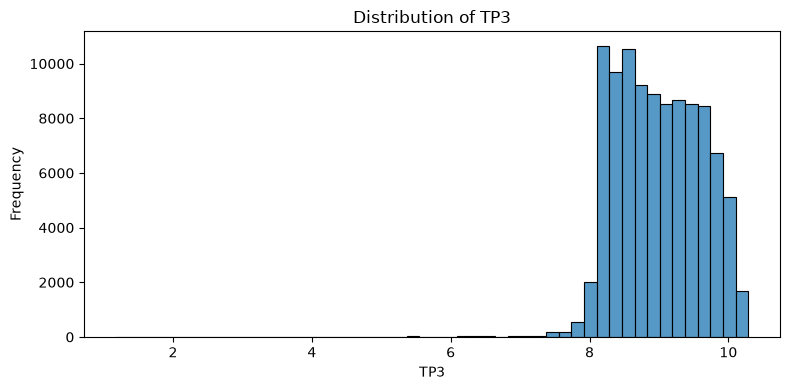

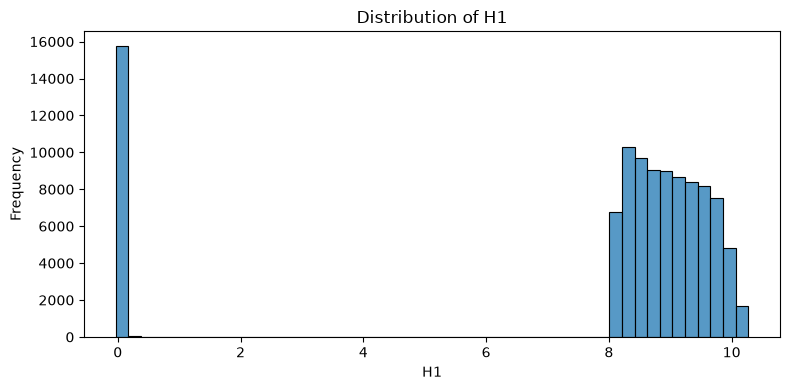

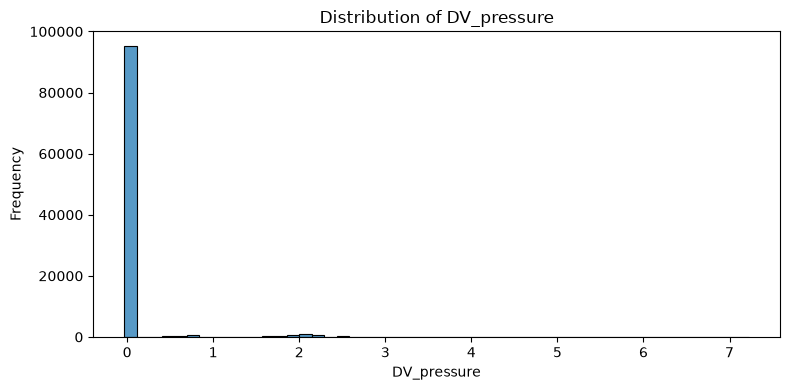

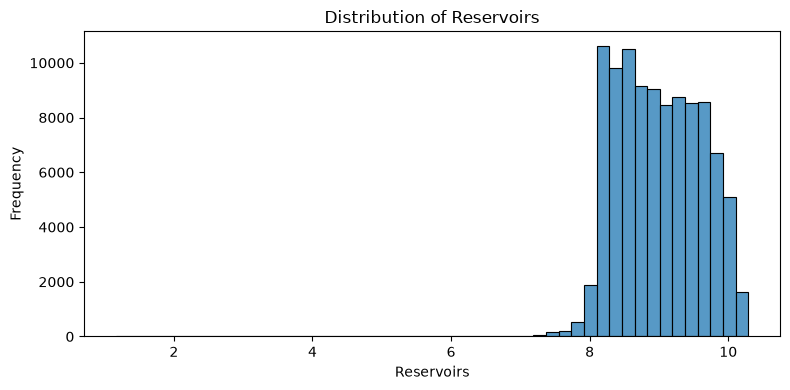

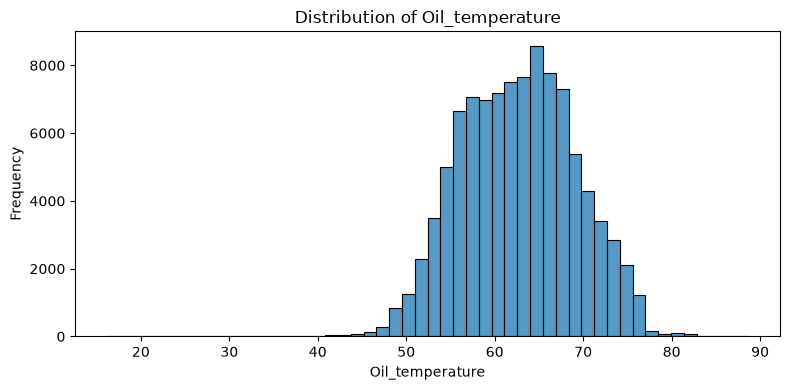

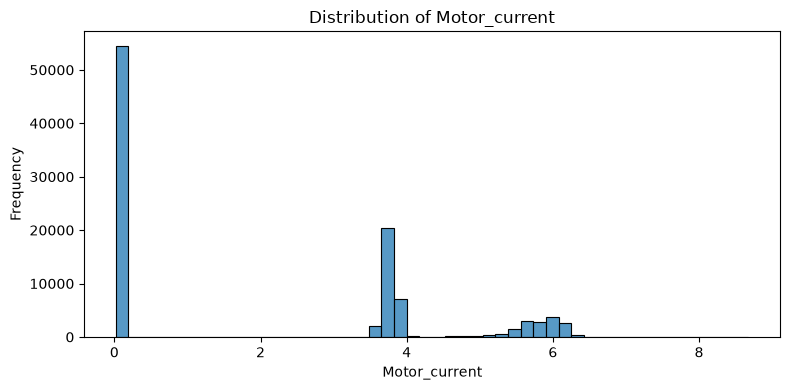

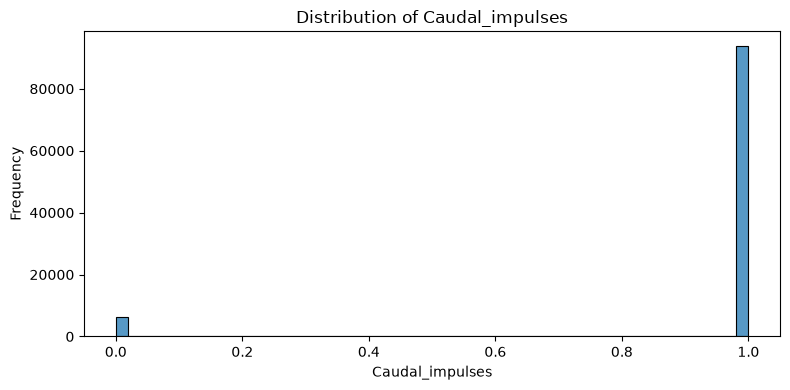

In [21]:
# 17. Sensor distribution plots
# Sampling keeps plotting efficient while preserving a broad view of distributions.
sample_size = min(100000, len(df_clean))
distribution_sample = df_clean.sample(n=sample_size, random_state=42)
print("Distribution plot sample size:", sample_size)

for sensor in available_numerical_sensors:
    plt.figure(figsize=(8, 4))
    sns.histplot(distribution_sample[sensor], bins=50)
    plt.title(f"Distribution of {sensor}")
    plt.xlabel(sensor)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(OUTPUT_FIGURES_DIR / f"{sensor}_distribution.png", dpi=300)
    plt.show()

In [22]:
# 18. Load or create documented failure events table
failure_events_path = OUTPUT_TABLES_DIR / "documented_failure_events.csv"

if failure_events_path.exists():
    failure_events = pd.read_csv(failure_events_path)
else:
    failure_events = pd.DataFrame({
        "event_id": ["F1", "F2", "F3", "F4"],
        "failure_type": ["Air leak", "Air leak", "Air leak", "Air leak"],
        "failure_start": [
            "2020-04-18 00:00",
            "2020-05-29 23:30",
            "2020-06-05 10:00",
            "2020-07-15 14:30"
        ],
        "failure_end": [
            "2020-04-18 23:59",
            "2020-05-30 06:00",
            "2020-06-07 14:30",
            "2020-07-15 19:00"
        ]
    })

failure_events["failure_start"] = pd.to_datetime(failure_events["failure_start"])
failure_events["failure_end"] = pd.to_datetime(failure_events["failure_end"])
failure_events.to_csv(OUTPUT_TABLES_DIR / "documented_failure_events.csv", index=False)
failure_events

,event_id,failure_type,failure_start,failure_end,inside_dataset_range
0,F1,Air leak,2020-04-18 00:00:00,2020-04-18 23:59:00,True
1,F2,Air leak,2020-05-29 23:30:00,2020-05-30 06:00:00,True
2,F3,Air leak,2020-06-05 10:00:00,2020-06-07 14:30:00,True
3,F4,Air leak,2020-07-15 14:30:00,2020-07-15 19:00:00,True


In [23]:
# 19. Check failure events against dataset range
dataset_start = df_clean[timestamp_col].min()
dataset_end = df_clean[timestamp_col].max()

failure_events["inside_dataset_range"] = (
    (failure_events["failure_start"] >= dataset_start) &
    (failure_events["failure_end"] <= dataset_end)
)

failure_events.to_csv(OUTPUT_TABLES_DIR / "documented_failure_events_checked.csv", index=False)
failure_events

,event_id,failure_type,failure_start,failure_end,inside_dataset_range
0,F1,Air leak,2020-04-18 00:00:00,2020-04-18 23:59:00,True
1,F2,Air leak,2020-05-29 23:30:00,2020-05-30 06:00:00,True
2,F3,Air leak,2020-06-05 10:00:00,2020-06-07 14:30:00,True
3,F4,Air leak,2020-07-15 14:30:00,2020-07-15 19:00:00,True


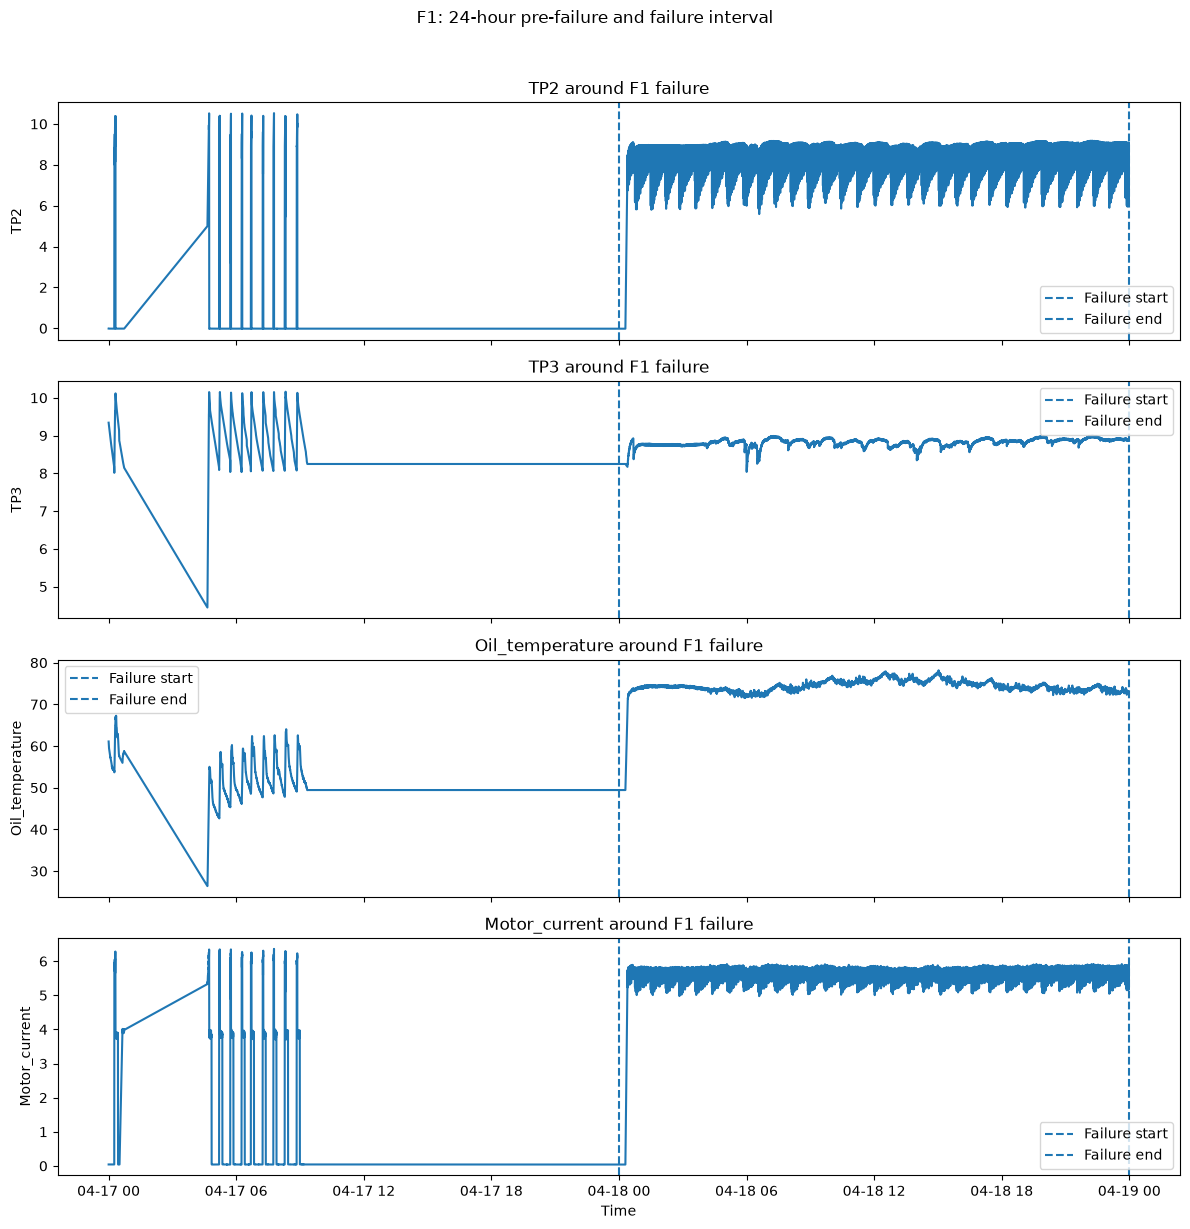

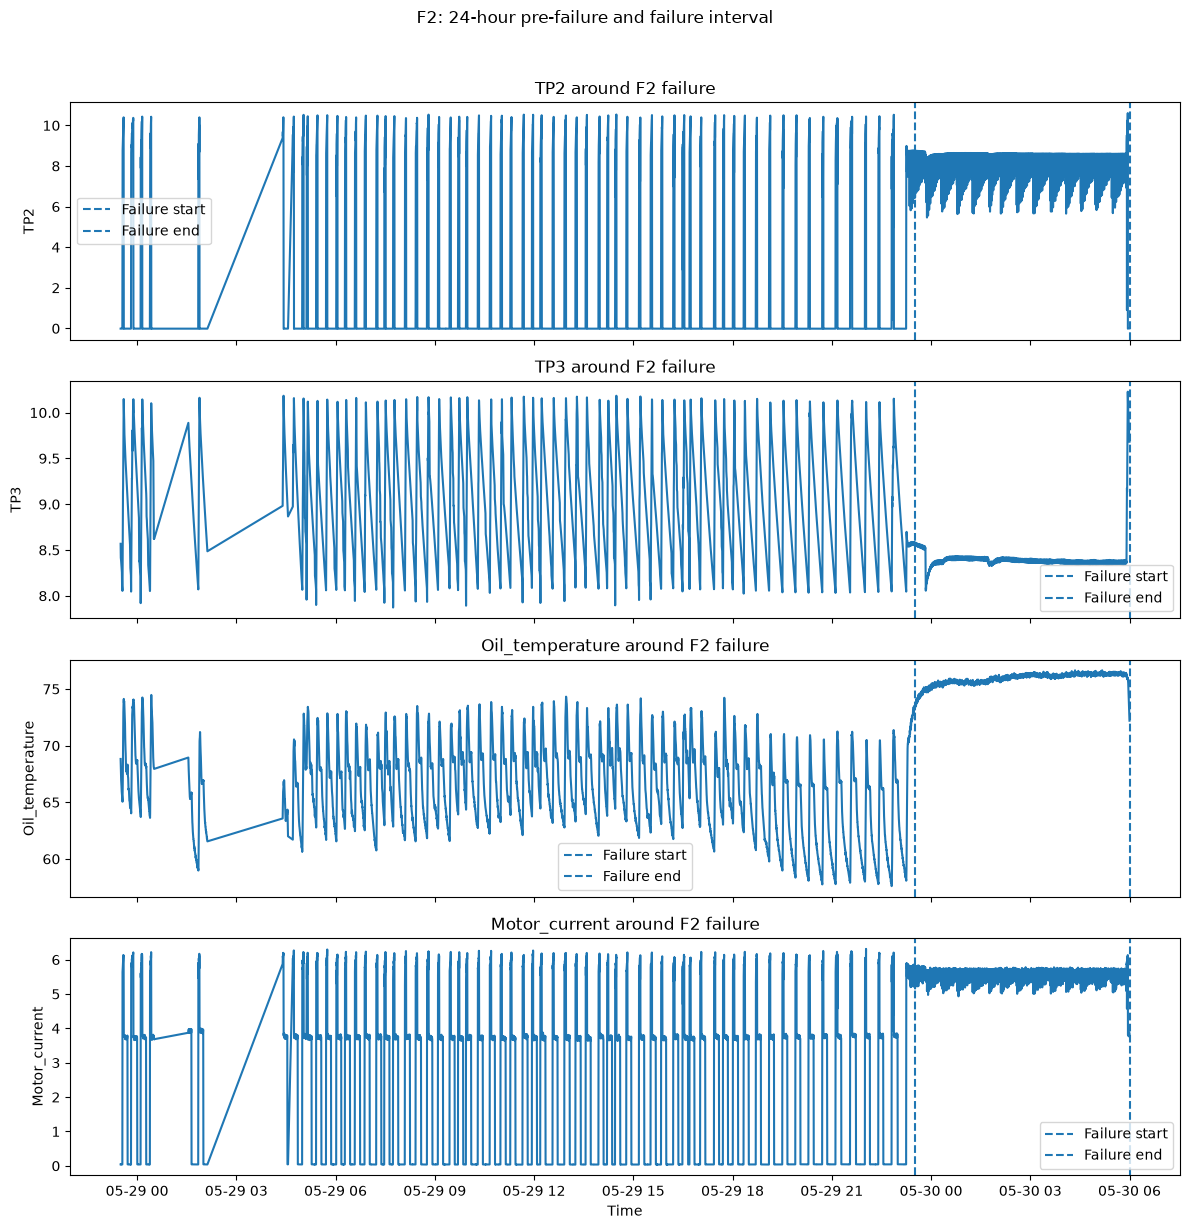

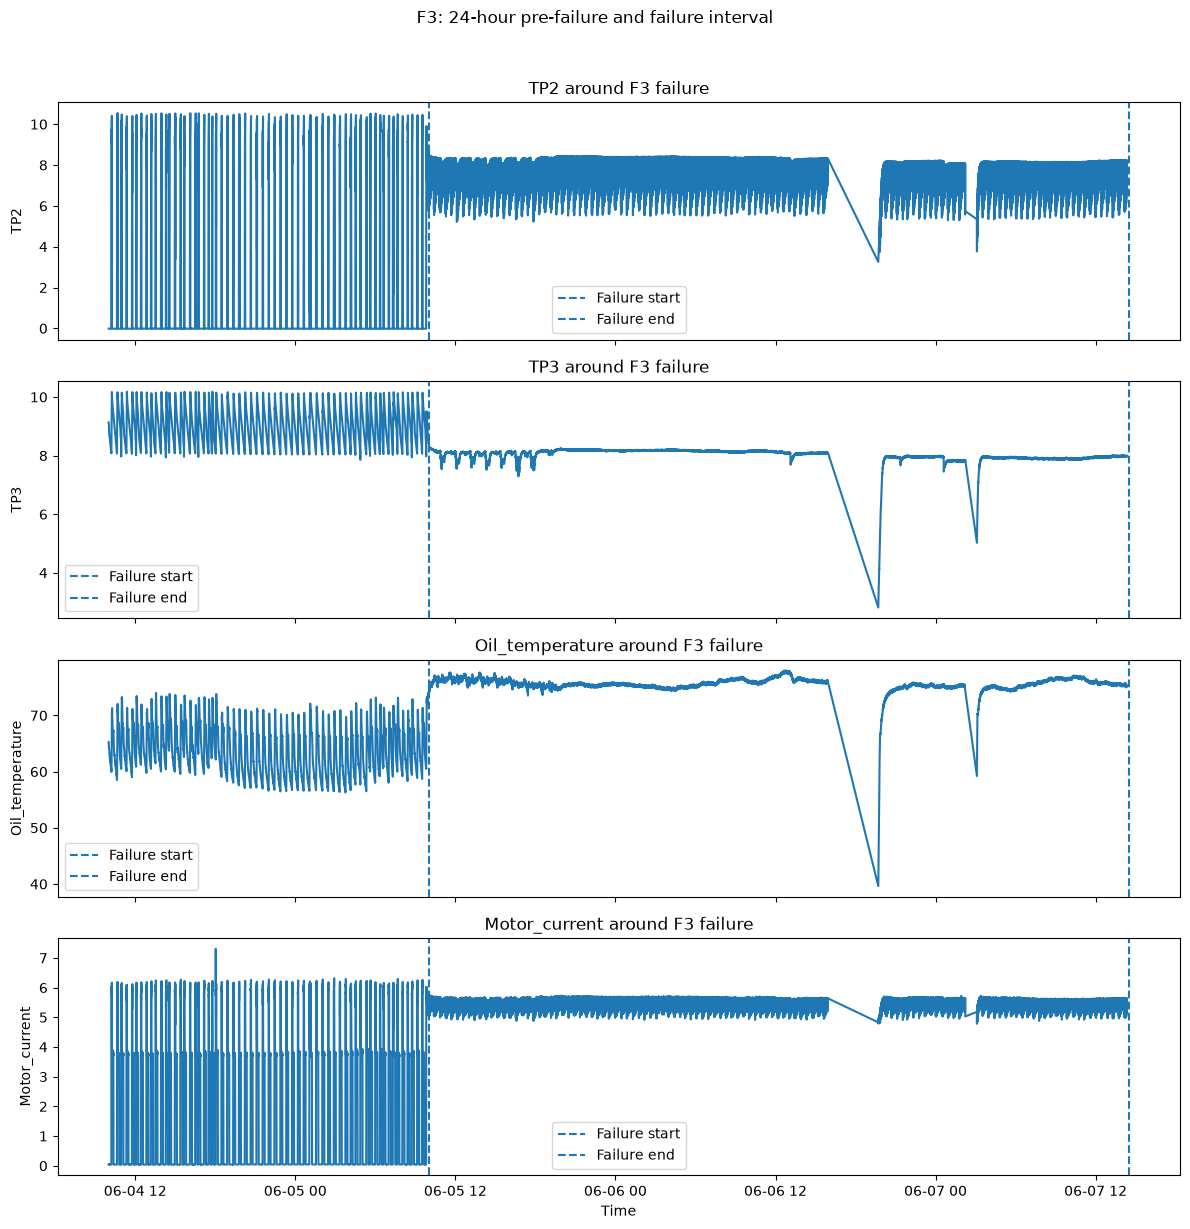

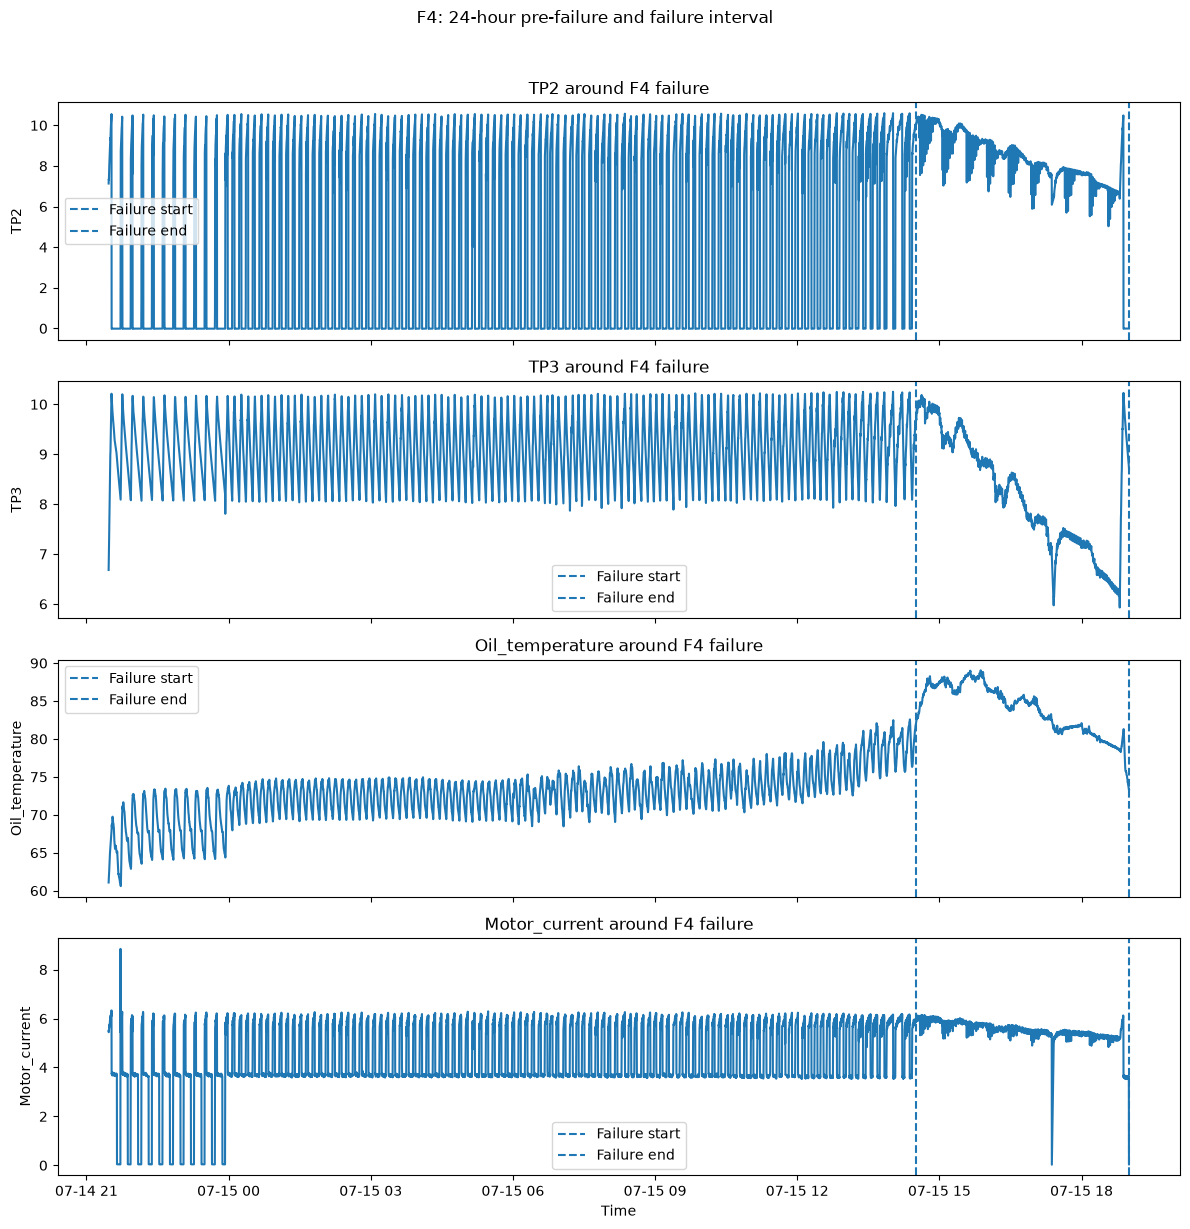

In [24]:
# 20. Plot 24 hours before each documented failure event
failure_plot_sensors = [
    col for col in ["TP2", "TP3", "Oil_temperature", "Motor_current"]
    if col in df_clean.columns
]

if len(failure_plot_sensors) == 0:
    raise ValueError("No failure plot sensors found in the dataset.")

for _, event in failure_events.iterrows():
    event_id = event["event_id"]
    failure_start = event["failure_start"]
    failure_end = event["failure_end"]

    window_start = failure_start - pd.Timedelta(hours=24)
    window_end = failure_end

    event_window = df_clean[
        (df_clean[timestamp_col] >= window_start) &
        (df_clean[timestamp_col] <= window_end)
    ].copy()

    if event_window.empty:
        print(f"No data found for {event_id}")
        continue

    fig, axes = plt.subplots(
        len(failure_plot_sensors), 1,
        figsize=(12, 3 * len(failure_plot_sensors)),
        sharex=True
    )

    if len(failure_plot_sensors) == 1:
        axes = [axes]

    for ax, sensor in zip(axes, failure_plot_sensors):
        ax.plot(event_window[timestamp_col], event_window[sensor])
        ax.axvline(failure_start, linestyle="--", label="Failure start")
        ax.axvline(failure_end, linestyle="--", label="Failure end")
        ax.set_title(f"{sensor} around {event_id} failure")
        ax.set_ylabel(sensor)
        ax.legend()

    axes[-1].set_xlabel("Time")
    fig.suptitle(f"{event_id}: 24-hour pre-failure and failure interval", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_FIGURES_DIR / f"failure_window_{event_id}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [25]:
# 21. Create EDA completion checklist
eda_checklist = pd.DataFrame({
    "task": [
        "Raw dataset loaded",
        "Timestamp parsed",
        "Data sorted chronologically",
        "Duplicate timestamps checked",
        "Missing values checked",
        "Missing values handled",
        "Cleaned dataset saved",
        "Sensor summary statistics saved",
        "Correlation heatmap created",
        "Sensor distributions created",
        "Failure-window plots created"
    ],
    "status": ["Complete"] * 11
})

eda_checklist.to_csv(OUTPUT_TABLES_DIR / "eda_completion_checklist.csv", index=False)
eda_checklist

,task,status
0,Raw dataset loaded,Complete
1,Timestamp parsed,Complete
2,Data sorted chronologically,Complete
3,Duplicate timestamps checked,Complete
4,Missing values checked,Complete
5,Missing values handled,Complete
6,Cleaned dataset saved,Complete
7,Sensor summary statistics saved,Complete
8,Correlation heatmap created,Complete
9,Sensor distributions created,Complete


In [26]:
# 22. Confirm saved outputs
print("Saved tables:")
for file in sorted(OUTPUT_TABLES_DIR.glob("*.csv")):
    print("-", file.name)

print("\nSaved figures:")
for file in sorted(OUTPUT_FIGURES_DIR.glob("*.png")):
    print("-", file.name)

Saved tables:
- column_data_types.csv
- column_metadata.csv
- correlation_matrix.csv
- dataset_summary.csv
- documented_failure_events.csv
- documented_failure_events_checked.csv
- duplicate_timestamps_summary.csv
- eda_completion_checklist.csv
- missing_values_before_after.csv
- missing_values_summary.csv
- preprocessing_summary.csv
- sensor_groups.csv
- sensor_summary_statistics.csv
- variable_groups.csv

Saved figures:
- Caudal_impulses_distribution.png
- Caudal_impulses_hourly_timeseries.png
- correlation_heatmap.png
- DV_pressure_distribution.png
- DV_pressure_hourly_timeseries.png
- failure_window_F1.png
- failure_window_F2.png
- failure_window_F3.png
- failure_window_F4.png
- H1_distribution.png
- H1_hourly_timeseries.png
- key_sensor_hourly_trends.png
- Motor_current_distribution.png
- Motor_current_hourly_timeseries.png
- Oil_temperature_distribution.png
- Oil_temperature_hourly_timeseries.png
- Reservoirs_distribution.png
- Reservoirs_hourly_timeseries.png
- TP2_distribution.

## End of Notebook 02

At this point, the cleaned dataset and EDA outputs have been created.

Next notebook: `03_feature_engineering.ipynb`

The next phase will create:
- 15-minute rolling features,
- 60-minute rolling features,
- 5-minute, 15-minute and 60-minute lag features,
- rate-of-change features,
- pressure-difference features.